In [16]:
# Import Libraries
import numpy as np
import pandas as pd
import os
import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample, class_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc

# Import model
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
from model.lstm_cupy_optimized import LSTMModelGPUOptimized, GPU_AVAILABLE


In [17]:
# === 1. Load Data ===
DATA_DIR = os.path.join(os.getcwd(), '..', 'data')
RAW_DATA = os.path.join(DATA_DIR, 'raw_dataset.csv')
df = pd.read_csv(RAW_DATA)

# Check GPU
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("✅ CuPy detected - Using GPU acceleration")
    use_gpu = True
except ImportError:
    import numpy as cp
    GPU_AVAILABLE = False
    print("⚠️ CuPy not found - Falling back to NumPy (CPU)")
    use_gpu = False

✅ CuPy detected - Using GPU acceleration


In [ ]:
# === 1.2 EDA ===
df.head()

In [18]:
# === 2. Preprocess Data ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df[df['Type'].str.contains('restoration', case=False, na=False)]
df['Priority'] = pd.to_numeric(df['Priority'], errors='coerce')
df['Impact'] = pd.to_numeric(df['Impact'], errors='coerce')
df['incident'] = ((df['Priority'] >= 2) & (df['Impact'] >= 2)).astype(int)


In [ ]:
# === 3. Base Functions/Procedures ===
# === 3.1 Windowing Function ===
def create_windowed_dataset(df, feature_cols, target_col, window_size):
    X, y, timestamps = [], [], []
    for i in range(len(df) - window_size):
        window = df[feature_cols].iloc[i:i+window_size].astype(float).values
        label = df[target_col].iloc[i+window_size]
        timestamp = df['Timestamp'].iloc[i+window_size]
        X.append(window)
        y.append(label)
        timestamps.append(timestamp)
    return np.array(X), np.array(y), np.array(timestamps)
        

In [20]:
# === 4. Training ===
def train_eval(X, y, label, cw=1, hidden_size=128, patience=10, epochs=100, batch_size=128, lr=0.005, print_every=1, lambda_l2=0.001):
    """
    Train and evaluate LSTM model with proper train/validation split
    
    Args:
        X: Input sequences
        y: Labels
        label: Experiment label
        cw: Class weight for minority class (default=1, no weighting)
        hidden_size: LSTM hidden units
        patience: Early stopping patience
        epochs: Max training epochs
        batch_size: Batch size
        lr: Learning rate
        print_every: Print frequency
        lambda_l2: L2 regularization strength
    """
    # Split: 60% train, 20% val, 20% test
    X_temp, X_te, y_temp, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_tr, X_val, y_tr, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)
    
    input_size = X.shape[2]  # Auto-detect from data shape

    # Initialize Model with class weight
    model = LSTMModelGPUOptimized(input_size=input_size, hidden_size=hidden_size, cw=cw)
    start_time = time.time()
    
    history = model.train(
        X_tr, y_tr,
        X_val, y_val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        print_every=print_every,
        patience=patience,
        lambda_l2=lambda_l2
    )
    duration = time.time() - start_time
    
    # Evaluate on test set
    y_prob = model.predict(X_te, batch_size=batch_size)
    y_prob = y_prob.flatten() if hasattr(y_prob, 'flatten') else y_prob
    y_pred = (y_prob >= 0.5).astype(int)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc_score = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_score:.3f})", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {label}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Calculate metrics
    return {
        'Model': label,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1_Score': f1_score(y_te, y_pred, zero_division=0),
        'AUC': auc_score,
        'TrainingTime': duration,
        'TrainableParams': model.count_params() if hasattr(model, 'count_params') else 0,
        'ClassWeight': cw
    }



Sampling Period: 30min

  Window Size: 48
    Data: 14592 samples, Class 0: 10112, Class 1: 4480
    → Running SMOTE...
Training: 12134 samples, 95 batches/epoch, batch_size=128
Validation: 4045 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.5930 | Val Loss: 0.5669 | Val Acc: 0.6873 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5709 | Val Loss: 0.5618 | Val Acc: 0.6890 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5662 | Val Loss: 0.5479 | Val Acc: 0.6927 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5532 | Val Loss: 0.5541 | Val Acc: 0.6601 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5530 | Val Loss: 0.5363 | Val Acc: 0.7164 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5437 | Val Loss: 0.5395 | Val Acc: 0.6865 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5404 | Val Loss: 0.5316 | Val Acc: 0.7016 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5353 | Val Loss: 0.5192 | Val Acc: 0.7251 [UNDER

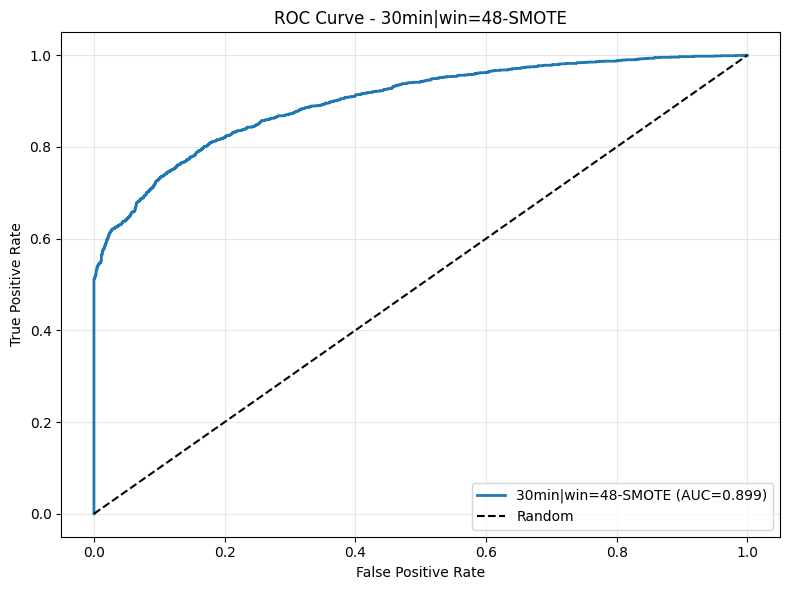


✅ Experiment completed! Total results: 1


In [21]:
# === 5. Run Experiment ==
sampling_periods = ['30min']
window_sizes = [48]
results_all = []

for sp in sampling_periods:
    print(f"\n{'='*60}")
    print(f"Sampling Period: {sp}")
    print('='*60)
    
    df_resampled = (df.set_index('Timestamp')
                      .resample(sp)
                      .agg({'incident': 'sum', 'Priority': 'mean', 'Impact': 'mean'})
                      .fillna(0)
                      .reset_index())
    df_resampled['incident'] = (df_resampled['incident'] > 0).astype(int)

    for win in window_sizes:
        print(f"\n  Window Size: {win}")
        X, y, ts = create_windowed_dataset(df_resampled, ['Priority', 'Impact'], 'incident', win)
        
        if len(X) < 200 or len(np.unique(y)) < 2:
            print(f"    ⚠️ Skipped: Insufficient data (samples={len(X)}, classes={len(np.unique(y))})")
            continue

        X_flat = X.reshape((X.shape[0], -1))
        df_xy = pd.DataFrame(X_flat).assign(label=y)
        maj, min_class = df_xy[df_xy.label==0], df_xy[df_xy.label==1]
        
        if len(min_class) < 50:
            print(f"    ⚠️ Skipped: Too few minority samples ({len(min_class)})")
            continue

        print(f"    Data: {len(X)} samples, Class 0: {len(maj)}, Class 1: {len(min_class)}")

        # # 1. Undersampling
        # if len(maj) >= len(min_class):
        #     maj_down = resample(maj, replace=False, n_samples=len(min_class), random_state=42)
        #     under = pd.concat([maj_down, min_class])
        #     Xu = under.drop('label', axis=1).values.reshape((-1, win, 2))
        #     yu = under.label.values
            
        #     print(f"    → Running Undersampling...")
        #     result = train_eval(Xu, yu, label=f"{sp}|win={win}-Undersampled")
        #     results_all.append(result)

        # 2. SMOTE
        try:
            print(f"    → Running SMOTE...")
            X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_flat, y)
            Xs = X_sm.reshape((-1, win, 2))
            result = train_eval(Xs, y_sm, label=f"{sp}|win={win}-SMOTE")
            results_all.append(result)
        except Exception as e:
            print(f"    ✗ SMOTE failed: {e}")
            continue

        # # 3. Class Weight (weighted loss on original imbalanced data)
        # cw_vals = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
        # cw_ratio = cw_vals[1] / cw_vals[0]  # Relative weight for class 1
        # print(f"    → Running with Class Weight: {cw_ratio:.2f}x for minority class")
        # result = train_eval(X, y, label=f"{sp}|win={win}-ClassWeight", cw=cw_ratio)
        # results_all.append(result)

print(f"\n{'='*60}")
print(f"✅ Experiment completed! Total results: {len(results_all)}")
print('='*60)


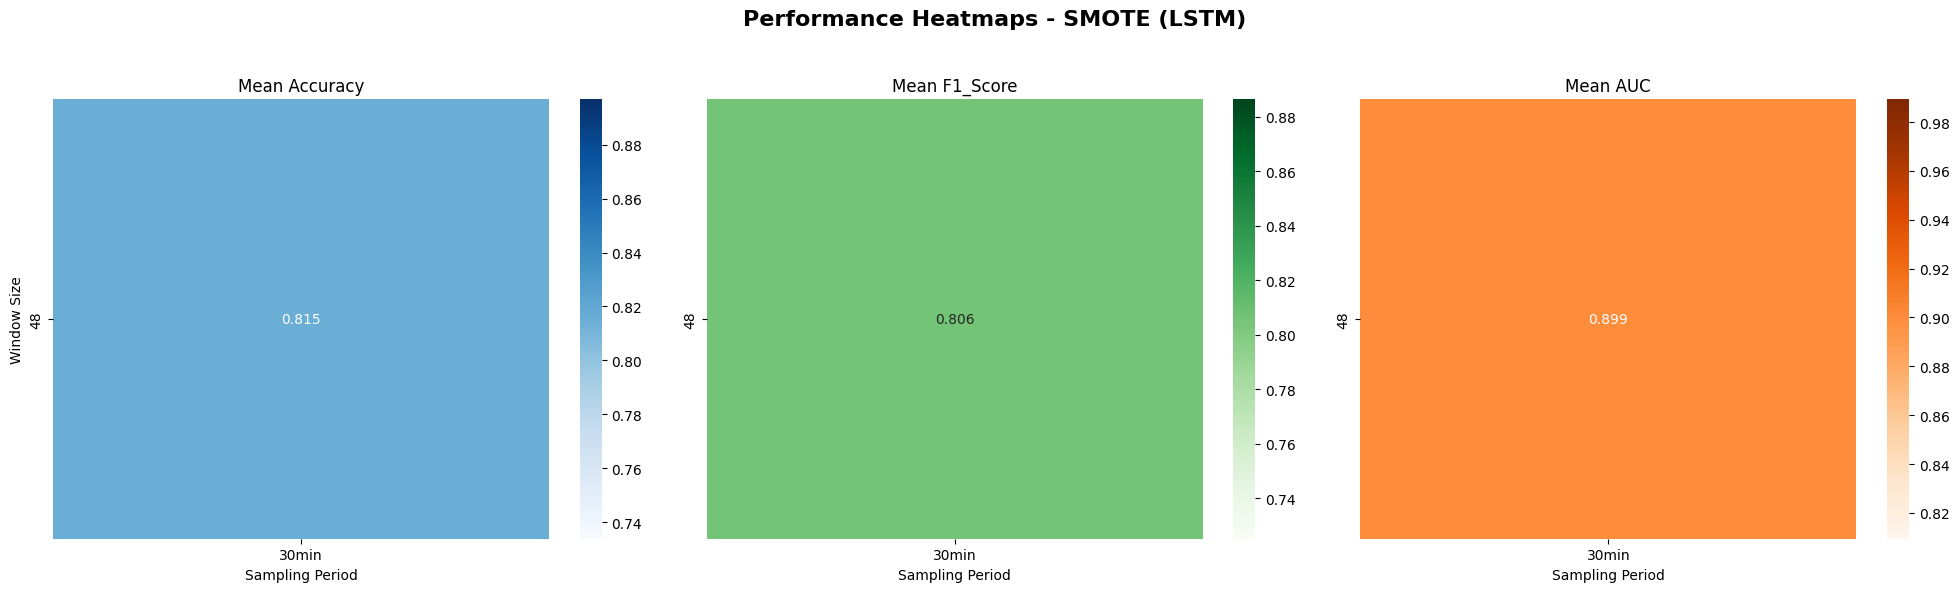


📊 FINAL COMPARATIVE METRICS TABLE


,Model,Type,Method,Accuracy,Precision,Recall,F1_Score,AUC,TrainingTime,TrainableParams
0,30min|win=48-SMOTE,LSTM,SMOTE,0.8153,0.8493,0.7666,0.8058,0.8994,1170.6252,0


In [29]:
# === 6. Final Results Visualization & Comparison ===
# 1. Convert the results list to a Pandas DataFrame
res_df = pd.DataFrame(results_all)

# 2. Metadata Extraction
# Extracts Sampling Period (e.g., 30min) and Window Size (e.g., 48) from the Model string
res_df[['Sampling','Window']] = res_df['Model'].str.extract(r'(\d+h|\d+min)\|win=(\d+)')
res_df['Window'] = res_df['Window'].fillna(0).astype(int)
res_df['Sampling'] = res_df['Sampling'].fillna('Unknown')

# Identify the Balancing Method (SMOTE, Undersampled, etc.)
res_df['Method'] = res_df['Model'].apply(lambda m:
        'SMOTE' if 'SMOTE' in m else
        'Undersampled' if 'Under' in m else
        'ClassWeight' if 'ClassWeight' in m else
        'Original')

# Identify the Architecture (Default to LSTM based on your Optimized GPU model)
res_df['Type'] = res_df['Model'].apply(lambda m: 
        'GRU' if 'GRU' in m else 
        'Transformer' if 'Transformer' in m else 
        'LSTM')

# 3. Performance Heatmaps (Accuracy, F1, AUC)
metrics = ['Accuracy', 'F1_Score', 'AUC']
cmaps = ['Blues', 'Greens', 'Oranges']

for method in res_df['Method'].unique():
    df_m = res_df[res_df['Method'] == method]
    for model_type in df_m['Type'].unique():
        df_sub = df_m[df_m['Type'] == model_type]
        
        # Validation: Skip if the filtered dataframe is empty to avoid ValueErrors
        if df_sub.empty:
            continue
            
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle(f"Performance Heatmaps - {method} ({model_type})", fontsize=16, fontweight='bold')
        
        for i, metric in enumerate(metrics):
            # Pivot data: X-axis (Sampling), Y-axis (Window)
            pivot = df_sub.pivot_table(index='Window', columns='Sampling', values=metric, aggfunc='mean')
            
            if not pivot.empty:
                sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmaps[i], ax=axes[i])
            else:
                axes[i].text(0.5, 0.5, 'Insufficient Data', ha='center', va='center')
                
            axes[i].set_title(f"Mean {metric}")
            axes[i].set_xlabel('Sampling Period')
            axes[i].set_ylabel('Window Size' if i == 0 else '')
            
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# 4. Comparative Summary Table
print("\n" + "="*70)
print("📊 FINAL COMPARATIVE METRICS TABLE")
print("="*70)
# Sort by F1_Score descending to see the best performing models at the top
final_table = res_df[['Model', 'Type', 'Method', 'Accuracy', 'Precision', 'Recall', 
                      'F1_Score', 'AUC', 'TrainingTime', 'TrainableParams']].sort_values(by='F1_Score', ascending=False)
display(final_table.round(4))

# 5. Confusion Matrix Visualization
# Note: This uses y_te and y_pred variables from the last successful training run in the loop
try:
    if 'y_te' in locals() or 'y_te' in globals():
        print("\n" + "="*70)
        print("📉 CONFUSION MATRIX (LAST EXPERIMENT RUN)")
        print("="*70)
        
        # y_pred comes from the thresholding logic in your train_eval function
        cm = confusion_matrix(y_te, y_pred)
        
        plt.figure(figsize=(7, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Normal (0)', 'Incident (1)'],
                    yticklabels=['Normal (0)', 'Incident (1)'])
        plt.title(f"Confusion Matrix: {res_df['Model'].iloc[-1]}", fontsize=14)
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        plt.show()
except NameError:
    print("\n[Notice]: y_te or y_pred not found. Ensure these are defined in your training cell to display the Confusion Matrix.")